## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import random

In [2]:
object_name = 'Documents_XVIII_century' # Books / Documents_XVIII_century

In [79]:
keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
preprocessing_method = 'logarithm' # normalization / logarithm

remove_outer = True
groups_to_remove = [0, 14]

elements_to_keep = [
                     'Al',
                     'S',
                     'Cr',
                     'Mn',
                     'Co',
                     'Cu',
                     'Zn',
                     'Pb'
                    ]

columns_to_keep_inks = {
                        'Books': [el + '_inks' for el in elements_to_keep],
                        'Documents_XVIII_century' : [el + '_inks' for el in elements_to_keep]
                        }

columns_to_keep_inds = { 
                        'Books' : [el + '_inds' for el in elements_to_keep],
                        'Documents_XVIII_century' : [el + '_inds' for el in elements_to_keep]
                        }

data_path = {'Books' : '../data/DANE.xlsx',
             'Documents_XVIII_century' : '../data/Listopad_2024.xlsx'}

results_path = {'Books' : '../results/Books/',
                'Documents_XVIII_century' : '../results/Documents_XVIII_century/'}

figures_path = {'Books' : '../results/visualisations/Books/',
                'Documents_XVIII_century' : '../results/visualisations/Documents_XVIII_century/'}

models_path = {'Books' : '../models/Books/',
                'Documents_XVIII_century' : '../models/Documents_XVIII_century/'}

## Loading the data

In [4]:
df = pd.ExcelFile(data_path[object_name])

if object_name == 'Books':
    # 1425: we are using only real samples, discarding simulated
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs

elif object_name == 'Documents_XVIII_century':
    inks_df = df.parse('Arkusz1', header=0, usecols=range(2,29), skiprows=range(3811, 4621))
    inds_df = df.parse('Arkusz1', header=0, usecols=range(32,59), skiprows=range(3811, 4621))
    inds_df.columns = inks_df.columns

## Preprocessing

### Joining corresponding samples from inds and inks into one table

In [5]:
inks_df = inks_df.reset_index(drop=False)
inds_df = inds_df.reset_index(drop=False)
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

In [6]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df[['nazwa próbki_inds', 'nazwa próbki_inks']][
#                 (inDKs_df['nazwa próbki_inds'].apply(
#                         lambda x: x[:4]) != inDKs_df['nazwa próbki_inks'].apply(
#                                         lambda x: x[:4]))
#                                                         ])

### Keeping track of the records from the same sample

In [7]:
inDKs_df['Sample_id'] = np.repeat(range(int(inDKs_df.shape[0]/15)), 15, axis=0)

In [8]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df)

### Removing some data

1. Let's remove 'outer' samples:

In [9]:
if remove_outer:
    inDKs_df = inDKs_df[inDKs_df['index_inds'].apply(lambda x: x%15 not in groups_to_remove)]

2. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [10]:
inDKs_df = inDKs_df[columns_to_keep_inks[object_name] + columns_to_keep_inds[object_name] + ['Sample_id']]

3. Let's remove rows with missing values.

In [13]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.007874015748031496

In [14]:
inDKs_df.dropna(inplace=True)

### Train test split, datasets, dataloaders

In [15]:
if keep_sample_together:
    
    indices = list(inDKs_df['Sample_id'].unique())
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    X_y_train = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_train)]
    X_y_val = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_val)]
    X_y_test = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_test)]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

else:
    indices = list(range(int(inDKs_df.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)
    
    partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}
    
    X_y_train = inDKs_df.iloc[partition['train'],:]
    X_y_val = inDKs_df.iloc[partition['val'],:]
    X_y_test = inDKs_df.iloc[partition['test'],:]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

### Creating features and labels matrices

In [16]:
train_order = X_y_train['Sample_id']
val_order = X_y_val['Sample_id']
test_order = X_y_test['Sample_id']

X_train = np.array(X_y_train[columns_to_keep_inds[object_name]].values)
y_train = np.array(X_y_train[columns_to_keep_inks[object_name]].values)
X_val = np.array(X_y_val[columns_to_keep_inds[object_name]].values)
y_val = np.array(X_y_val[columns_to_keep_inks[object_name]].values)
X_test = np.array(X_y_test[columns_to_keep_inds[object_name]].values)
y_test = np.array(X_y_test[columns_to_keep_inks[object_name]].values)

### Normalization / taking logarithm

In [17]:
def adjusted_log_transform(nonnegative_array):
    res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)
    res = np.where(res != 0, res, 2*res.min(axis=0))
    return res

In [18]:
if preprocessing_method == 'normalization':

    X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
    y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)

    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)
    
elif preprocessing_method == 'logarithm':
    
    X_train = adjusted_log_transform(X_train)
    y_train = adjusted_log_transform(y_train)
    
    X_val = adjusted_log_transform(X_val)
    y_val = adjusted_log_transform(y_val)
    X_test = adjusted_log_transform(X_test)
    y_test = adjusted_log_transform(y_test)
    
elif preprocessing_method == 'logarithm_and_normalization':
    
    #logarithm
    X_train = adjusted_log_transform(X_train)
    y_train = adjusted_log_transform(y_train)
    
    X_val = adjusted_log_transform(X_val)
    y_val = adjusted_log_transform(y_val)
    X_test = adjusted_log_transform(X_test)
    y_test = adjusted_log_transform(y_test)
    
    #normalization
    X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
    y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)

    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)

/tmp/ipykernel_44643/1324458353.py:2: RuntimeWarning: divide by zero encountered in log
  res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)


In [19]:
#plt.hist(X_val[:,2], bins=100)

### Converting to tensors

In [20]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [21]:
X_train = torch.Tensor(X_train).to(device)
y_train = torch.Tensor(y_train).to(device)
    
X_val = torch.Tensor(X_val).to(device)
y_val = torch.Tensor(y_val).to(device)
X_test = torch.Tensor(X_test).to(device)
y_test = torch.Tensor(y_test).to(device)

### Dataset

In [22]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [23]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [24]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Building neural network

In [25]:
input_size = X_train.shape[1]

For now, we keep only use very simple neural network. The layers are lineaer, each has the same number of neurons equal to the size of input (and, at the same time, size of output).

In [26]:
dropout_prob = 0.02

class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, 32),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(32, 64),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(64, 128),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(128, 256),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(32, input_size))
    def forward(self, x):
        return self.seq(x)

## Training

In [27]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): Dropout(p=0.02, inplace=False)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=64, bias=True)
    (4): Dropout(p=0.02, inplace=False)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=128, bias=True)
    (7): Dropout(p=0.02, inplace=False)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=256, bias=True)
    (10): Dropout(p=0.02, inplace=False)
    (11): ReLU()
    (12): Linear(in_features=256, out_features=128, bias=True)
    (13): Dropout(p=0.02, inplace=False)
    (14): ReLU()
    (15): Linear(in_features=128, out_features=64, bias=True)
    (16): Dropout(p=0.02, inplace=False)
    (17): ReLU()
    (18): Linear(in_features=64, out_features=32, bias=True)
    (19): Dropout(p=0.02, inplace=False)
    (20): ReLU()
    (21): Linear(in_features=32, out_features=8, bias=True)
  )
)


In [28]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

In [29]:
weights = torch.tensor([1/8,1/8,1/8,1/8,1/8,1/8,1/8,1/8]).unsqueeze(1).to(device)

class CustomLoss(nn.Module):
    def __init__(self, weights=weights):
        super(CustomLoss, self).__init__()
        self.weights = weights
        assert weights.shape[1] == 1

    def forward(self, outputs, targets):
        inner_loss = nn.L1Loss(reduction='none')
        res = inner_loss(outputs, targets)
        res = torch.mm(res, self.weights)
        res = res.mean(axis=0)
#         inner_loss_to_compare = nn.L1Loss(reduction='mean')
#         assert torch.isclose(inner_loss_to_compare(outputs, targets), res)
        return res

In [30]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss*(1-dropout_prob)))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 3.0906748175621033 test 2.3811539366882264
EPOCH 2:
LOSS train 1.9212763905525208 test 1.3275879383523956
EPOCH 3:
LOSS train 1.2639793515205384 test 1.1593265038164517
EPOCH 4:
LOSS train 1.2136460483074187 test 1.1350477716331262
EPOCH 5:
LOSS train 1.1780766010284425 test 1.0824912717770074
EPOCH 6:
LOSS train 1.1562716722488404 test 1.1013716528952577
EPOCH 7:
LOSS train 1.156552505493164 test 1.068945476085175
EPOCH 8:
LOSS train 1.1552621483802796 test 1.0738307094009778
EPOCH 9:
LOSS train 1.1460001170635223 test 1.0667763038546074
EPOCH 10:
LOSS train 1.1310514986515046 test 1.0540105934798263
EPOCH 11:
LOSS train 1.1155091524124146 test 1.027673972936532
EPOCH 12:
LOSS train 1.078456237912178 test 0.9684155613557073
EPOCH 13:
LOSS train 1.0323413789272309 test 0.9474277274895261
EPOCH 14:
LOSS train 1.0116283625364304 test 0.9692584452046693
EPOCH 15:
LOSS train 0.9966301143169403 test 0.977471022769695
EPOCH 16:
LOSS train 0.9747441589832306 test 0.9282254

LOSS train 0.5243043765425682 test 0.49021662787581216
EPOCH 131:
LOSS train 0.5177381679415702 test 0.473849618684472
EPOCH 132:
LOSS train 0.519450207054615 test 0.47960072502311857
EPOCH 133:
LOSS train 0.5159165039658546 test 0.49077489685557274
EPOCH 134:
LOSS train 0.5156941637396812 test 0.4815432689594858
EPOCH 135:
LOSS train 0.5139305233955384 test 0.478439147407772
EPOCH 136:
LOSS train 0.5068255886435509 test 0.4740019806916932
EPOCH 137:
LOSS train 0.5099615305662155 test 0.47986019639886973
EPOCH 138:
LOSS train 0.5140762835741043 test 0.4839568525391226
EPOCH 139:
LOSS train 0.507107563316822 test 0.4688382330288869
EPOCH 140:
LOSS train 0.5106671124696731 test 0.4793165521608054
EPOCH 141:
LOSS train 0.5090057298541069 test 0.4756443456898209
EPOCH 142:
LOSS train 0.5052030086517334 test 0.46587406800721437
EPOCH 143:
LOSS train 0.509051975607872 test 0.46828972178788586
EPOCH 144:
LOSS train 0.5100041940808296 test 0.4906544851319481
EPOCH 145:
LOSS train 0.50531701594

LOSS train 0.4045614242553711 test 0.35816493659506315
EPOCH 256:
LOSS train 0.4055314913392067 test 0.37098448644316834
EPOCH 257:
LOSS train 0.40334556102752683 test 0.3619468249278214
EPOCH 258:
LOSS train 0.4040169730782509 test 0.3635470720124609
EPOCH 259:
LOSS train 0.39702477157115934 test 0.3600693316282207
EPOCH 260:
LOSS train 0.40487695634365084 test 0.3800480584734269
EPOCH 261:
LOSS train 0.3988776311278343 test 0.36538520318906725
EPOCH 262:
LOSS train 0.39609398543834684 test 0.36397987837759593
EPOCH 263:
LOSS train 0.40104741752147677 test 0.3702096395726877
EPOCH 264:
LOSS train 0.3989340752363205 test 0.3654145518957659
EPOCH 265:
LOSS train 0.4018621101975441 test 0.36227982570060335
EPOCH 266:
LOSS train 0.393060901761055 test 0.36589329954344807
EPOCH 267:
LOSS train 0.3994267672300339 test 0.36336852201955916
EPOCH 268:
LOSS train 0.3921325773000717 test 0.36617558119906723
EPOCH 269:
LOSS train 0.39532104432582854 test 0.3717654935526484
EPOCH 270:
LOSS train 0

LOSS train 0.33525455743074417 test 0.3043077289751013
EPOCH 381:
LOSS train 0.3472960278391838 test 0.30267113821936475
EPOCH 382:
LOSS train 0.3443267628550529 test 0.3070753776629008
EPOCH 383:
LOSS train 0.33424952179193496 test 0.3040315752197768
EPOCH 384:
LOSS train 0.33926437348127364 test 0.31912881368489665
EPOCH 385:
LOSS train 0.33384981006383896 test 0.3198459837954235
EPOCH 386:
LOSS train 0.3377123326063156 test 0.3139507034122944
EPOCH 387:
LOSS train 0.3368090406060219 test 0.3142782653745349
EPOCH 388:
LOSS train 0.3379876807332039 test 0.30788223383149116
EPOCH 389:
LOSS train 0.3367298752069473 test 0.30075787850179286
EPOCH 390:
LOSS train 0.33465757220983505 test 0.29891698970093983
EPOCH 391:
LOSS train 0.3361683711409569 test 0.3133778104823054
EPOCH 392:
LOSS train 0.33115574568510053 test 0.30504839560150643
EPOCH 393:
LOSS train 0.3325161889195442 test 0.31087989218680917
EPOCH 394:
LOSS train 0.34024096727371217 test 0.3001724392746696
EPOCH 395:
LOSS train 

LOSS train 0.30069669187068937 test 0.27371770861835876
EPOCH 506:
LOSS train 0.288798551261425 test 0.27817428330053356
EPOCH 507:
LOSS train 0.2966389015316963 test 0.2721278823831382
EPOCH 508:
LOSS train 0.29514494985342027 test 0.2696837014616218
EPOCH 509:
LOSS train 0.2971294760704041 test 0.2688419019012278
EPOCH 510:
LOSS train 0.29359050989151003 test 0.27027587187699686
EPOCH 511:
LOSS train 0.29460338950157167 test 0.26684374262176397
EPOCH 512:
LOSS train 0.29124822914600373 test 0.2707509806177771
EPOCH 513:
LOSS train 0.287343667447567 test 0.2753890716193514
EPOCH 514:
LOSS train 0.29037430286407473 test 0.26829691108105747
EPOCH 515:
LOSS train 0.291243177652359 test 0.28303797991960555
EPOCH 516:
LOSS train 0.2975209027528763 test 0.27760751661265853
EPOCH 517:
LOSS train 0.2878811225295067 test 0.26713870154014074
EPOCH 518:
LOSS train 0.2902503937482834 test 0.26991248519570776
EPOCH 519:
LOSS train 0.293073345720768 test 0.25925214091421084
EPOCH 520:
LOSS train 0.

...

LOSS train 0.14627174697816372 test 0.19398321319741146
EPOCH 4419:
LOSS train 0.15177917554974557 test 0.1906087799230946
EPOCH 4420:
LOSS train 0.14539291858673095 test 0.1941796122407754
EPOCH 4421:
LOSS train 0.14540402181446552 test 0.1925188152705895
EPOCH 4422:
LOSS train 0.1457817904651165 test 0.19291513443863345
EPOCH 4423:
LOSS train 0.14448108933866025 test 0.19497872102385716
EPOCH 4424:
LOSS train 0.14282954595983027 test 0.1891093348469443
EPOCH 4425:
LOSS train 0.14598998092114926 test 0.19062009491652024
EPOCH 4426:
LOSS train 0.14365140870213508 test 0.1945964745403701
EPOCH 4427:
LOSS train 0.14493979662656784 test 0.19812767470519962
EPOCH 4428:
LOSS train 0.14648719914257527 test 0.19689212649969653
EPOCH 4429:
LOSS train 0.14400389418005943 test 0.19111679129780249
EPOCH 4430:
LOSS train 0.14999618604779244 test 0.19244256047096872
EPOCH 4431:
LOSS train 0.14280254915356635 test 0.19290604650178028
EPOCH 4432:
LOSS train 0.1419099599123001 test 0.19207736711954795

LOSS train 0.14812023043632508 test 0.19983960039106033
EPOCH 4541:
LOSS train 0.15265222564339637 test 0.19553824074566364
EPOCH 4542:
LOSS train 0.1496485397219658 test 0.1916734319858765
EPOCH 4543:
LOSS train 0.1470017023384571 test 0.19337232327028994
EPOCH 4544:
LOSS train 0.14704527370631695 test 0.2007414647146263
EPOCH 4545:
LOSS train 0.15123792365193367 test 0.19405144953102102
EPOCH 4546:
LOSS train 0.14393556416034697 test 0.19445721104627348
EPOCH 4547:
LOSS train 0.1431677896529436 test 0.19608623068250772
EPOCH 4548:
LOSS train 0.14815486446022988 test 0.19322608172245154
EPOCH 4549:
LOSS train 0.14835749007761478 test 0.19399287701346946
EPOCH 4550:
LOSS train 0.15001864954829217 test 0.20225679282133133
EPOCH 4551:
LOSS train 0.14364139027893544 test 0.19405254284901016
EPOCH 4552:
LOSS train 0.1512012153863907 test 0.19136242276691753
EPOCH 4553:
LOSS train 0.13952506929636002 test 0.1948839891245802
EPOCH 4554:
LOSS train 0.14684141725301741 test 0.19133089429663339

LOSS train 0.14499341994524 test 0.19236054613520853
EPOCH 4663:
LOSS train 0.14221590720117092 test 0.19127699377717636
EPOCH 4664:
LOSS train 0.13827746361494064 test 0.19500908753304308
EPOCH 4665:
LOSS train 0.14051417112350464 test 0.1860051277804807
EPOCH 4666:
LOSS train 0.14680848643183708 test 0.1874786866709931
EPOCH 4667:
LOSS train 0.1425754800438881 test 0.18925678913244082
EPOCH 4668:
LOSS train 0.15032673999667168 test 0.19305261599596676
EPOCH 4669:
LOSS train 0.15118738487362862 test 0.19219138575658087
EPOCH 4670:
LOSS train 0.14971347972750665 test 0.19519896245730742
EPOCH 4671:
LOSS train 0.14567545279860497 test 0.19173111098367748
EPOCH 4672:
LOSS train 0.15037815719842912 test 0.19393334272321855
EPOCH 4673:
LOSS train 0.14369502738118173 test 0.18889298759662468
EPOCH 4674:
LOSS train 0.14082827754318714 test 0.19319454804074218
EPOCH 4675:
LOSS train 0.13851736970245837 test 0.19557802012824374
EPOCH 4676:
LOSS train 0.14610745571553707 test 0.1944880112547228

LOSS train 0.1387967512011528 test 0.1927763052959251
EPOCH 4785:
LOSS train 0.1460600145161152 test 0.19150523020571653
EPOCH 4786:
LOSS train 0.14375170022249223 test 0.18986975244597623
EPOCH 4787:
LOSS train 0.14421988278627396 test 0.19275241583858738
EPOCH 4788:
LOSS train 0.14100308828055858 test 0.18868142830000353
EPOCH 4789:
LOSS train 0.1485445886850357 test 0.1894900579862581
EPOCH 4790:
LOSS train 0.14645828641951084 test 0.19013554381459724
EPOCH 4791:
LOSS train 0.14258694984018802 test 0.18819129527121325
EPOCH 4792:
LOSS train 0.14585107415914536 test 0.19210013857011804
EPOCH 4793:
LOSS train 0.14587544985115528 test 0.19079161646370668
EPOCH 4794:
LOSS train 0.15029726475477218 test 0.1957233047915324
EPOCH 4795:
LOSS train 0.150339924916625 test 0.19370089340084837
EPOCH 4796:
LOSS train 0.1502400428056717 test 0.18695168790892336
EPOCH 4797:
LOSS train 0.14399393796920776 test 0.1889979407895385
EPOCH 4798:
LOSS train 0.139009215682745 test 0.1861713742645642
EPOCH

LOSS train 0.14497359097003937 test 0.18948031269639504
EPOCH 4907:
LOSS train 0.14976941868662835 test 0.19116925326325282
EPOCH 4908:
LOSS train 0.1411363735795021 test 0.1938992161205934
EPOCH 4909:
LOSS train 0.14290154688060283 test 0.1960323353243124
EPOCH 4910:
LOSS train 0.14035029299557208 test 0.1911219474651659
EPOCH 4911:
LOSS train 0.14371263459324837 test 0.19211877726297114
EPOCH 4912:
LOSS train 0.1439631000161171 test 0.19577652597245368
EPOCH 4913:
LOSS train 0.14444507285952568 test 0.19174110055561286
EPOCH 4914:
LOSS train 0.14352139160037042 test 0.19163888504418708
EPOCH 4915:
LOSS train 0.14398419223725795 test 0.19158320854626992
EPOCH 4916:
LOSS train 0.13737041614949702 test 0.1979683999291813
EPOCH 4917:
LOSS train 0.14028006047010422 test 0.19353053011659901
EPOCH 4918:
LOSS train 0.13861973732709884 test 0.1897519261856343
EPOCH 4919:
LOSS train 0.13997840657830238 test 0.18791521203734038
EPOCH 4920:
LOSS train 0.14429176561534404 test 0.19139184590503006

In [27]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss*(1-dropout_prob)))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 3.02472968723463 test 2.069694217487618
EPOCH 2:
LOSS train 1.555934128553971 test 1.2612442604093639
EPOCH 3:
LOSS train 1.2749034373656563 test 1.1689175121237836
EPOCH 4:
LOSS train 1.2164045675941135 test 1.1481304386975588
EPOCH 5:
LOSS train 1.2004244586695796 test 1.168562493942402
EPOCH 6:
LOSS train 1.1907930788786516 test 1.1367729636916408
EPOCH 7:
LOSS train 1.174826715303504 test 1.1177707709537612
EPOCH 8:
LOSS train 1.1489194009615027 test 1.073287489640492
EPOCH 9:
LOSS train 1.1031866280928901 test 1.023108510264644
EPOCH 10:
LOSS train 1.075775040232617 test 1.007784556304967
EPOCH 11:
LOSS train 1.0565749925115835 test 0.9844569382844148
EPOCH 12:
LOSS train 1.0266831672709922 test 0.9676754161494749
EPOCH 13:
LOSS train 1.0070607999096746 test 0.9441224900991829
EPOCH 14:
LOSS train 0.9860248565673828 test 0.908138872059407
EPOCH 15:
LOSS train 0.960618838019993 test 0.9140402659056364
EPOCH 16:
LOSS train 0.9473554284676261 test 0.88807345629290

LOSS train 0.5346706561420275 test 0.5034534961302523
EPOCH 131:
LOSS train 0.5383405970490497 test 0.4986347308837705
EPOCH 132:
LOSS train 0.5430434799712637 test 0.5140991316721947
EPOCH 133:
LOSS train 0.5461541608623837 test 0.5041013975896769
EPOCH 134:
LOSS train 0.5411841571331024 test 0.4998818689708908
EPOCH 135:
LOSS train 0.5359558981397877 test 0.5032564027635036
EPOCH 136:
LOSS train 0.5351923056270765 test 0.5146069875221562
EPOCH 137:
LOSS train 0.5279012490873751 test 0.4926223313228951
EPOCH 138:
LOSS train 0.5299090717149817 test 0.49088607196592626
EPOCH 139:
LOSS train 0.534970091736835 test 0.4970531657931429
EPOCH 140:
LOSS train 0.5276306141977725 test 0.4946746136924183
EPOCH 141:
LOSS train 0.5225593525430431 test 0.4988788050758066
EPOCH 142:
LOSS train 0.5379083337991134 test 0.5082976351499006
EPOCH 143:
LOSS train 0.5246778895025668 test 0.4866074020967439
EPOCH 144:
LOSS train 0.5164483124795167 test 0.49891539584569355
EPOCH 145:
LOSS train 0.52767549131

LOSS train 0.42415376461070514 test 0.39394717058373824
EPOCH 256:
LOSS train 0.41776825941127277 test 0.39981880459658525
EPOCH 257:
LOSS train 0.41035992295845697 test 0.40383193198039574
EPOCH 258:
LOSS train 0.4218860035357268 test 0.40232010098795096
EPOCH 259:
LOSS train 0.426881844582765 test 0.394654530255055
EPOCH 260:
LOSS train 0.4223594121311022 test 0.40520707517724347
EPOCH 261:
LOSS train 0.42074424157971924 test 0.3978680930976514
EPOCH 262:
LOSS train 0.41536737913670746 test 0.3922780377134956
EPOCH 263:
LOSS train 0.4202017550883086 test 0.39591754423247444
EPOCH 264:
LOSS train 0.4169669280881467 test 0.385954040914636
EPOCH 265:
LOSS train 0.4155654311180115 test 0.39587091118787177
EPOCH 266:
LOSS train 0.4170670898064323 test 0.3987388750565825
EPOCH 267:
LOSS train 0.42187394914419757 test 0.3949601362852586
EPOCH 268:
LOSS train 0.4128083185009334 test 0.38847617741812157
EPOCH 269:
LOSS train 0.4152518692223922 test 0.3929995412144948
EPOCH 270:
LOSS train 0.4

LOSS train 0.3572999562906182 test 0.3587395866877503
EPOCH 381:
LOSS train 0.35347062738045404 test 0.34869072049028343
EPOCH 382:
LOSS train 0.3516381719838018 test 0.3459867919753823
EPOCH 383:
LOSS train 0.3445836901664734 test 0.3445547498728114
EPOCH 384:
LOSS train 0.3480853451334912 test 0.3430228241995253
EPOCH 385:
LOSS train 0.35022226235140924 test 0.3363691698863275
EPOCH 386:
LOSS train 0.35172469590021216 test 0.3298988704776598
EPOCH 387:
LOSS train 0.3546370151250259 test 0.33848706322756633
EPOCH 388:
LOSS train 0.3554698786009913 test 0.3346542355776937
EPOCH 389:
LOSS train 0.35448402425517206 test 0.3349222585345032
EPOCH 390:
LOSS train 0.3492121035638063 test 0.3419457997278207
EPOCH 391:
LOSS train 0.35021129898403003 test 0.3459400524109326
EPOCH 392:
LOSS train 0.35293679263280786 test 0.34856414954488474
EPOCH 393:
LOSS train 0.3428579737310824 test 0.3458649645966512
EPOCH 394:
LOSS train 0.34473188934118854 test 0.33339563214392576
EPOCH 395:
LOSS train 0.3

LOSS train 0.30258729665175726 test 0.3006850170495885
EPOCH 506:
LOSS train 0.2992662217306054 test 0.30656388242625526
EPOCH 507:
LOSS train 0.3039884670920994 test 0.30708711638011865
EPOCH 508:
LOSS train 0.29195130519244983 test 0.3104322042633538
EPOCH 509:
LOSS train 0.2981114931728529 test 0.3041171387417449
EPOCH 510:
LOSS train 0.2952693778535594 test 0.31781077393848034
EPOCH 511:
LOSS train 0.3030955493450165 test 0.31001609487804
EPOCH 512:
LOSS train 0.3048053591147713 test 0.29555655200724246
EPOCH 513:
LOSS train 0.30577457728593244 test 0.3015284767112246
EPOCH 514:
LOSS train 0.306761234998703 test 0.3137957473306192
EPOCH 515:
LOSS train 0.3040021457101988 test 0.30853254683660686
EPOCH 516:
LOSS train 0.29801757957624353 test 0.3127972324723723
EPOCH 517:
LOSS train 0.30258096430612647 test 0.30601876831165065
EPOCH 518:
LOSS train 0.29712206902711286 test 0.30169546127112373
EPOCH 519:
LOSS train 0.2949863270572994 test 0.30157910508069175
EPOCH 520:
LOSS train 0.3

...

LOSS train 0.15211382054764291 test 0.2323566670536443
EPOCH 4425:
LOSS train 0.15027905287949936 test 0.23528913205799956
EPOCH 4426:
LOSS train 0.14964222713657047 test 0.23239098691002086
EPOCH 4427:
LOSS train 0.1489363740319791 test 0.2316720663221484
EPOCH 4428:
LOSS train 0.1486661434173584 test 0.23480335360047994
EPOCH 4429:
LOSS train 0.15307621495879215 test 0.23347309466209953
EPOCH 4430:
LOSS train 0.147207146105559 test 0.23704505490484062
EPOCH 4431:
LOSS train 0.14467366169328275 test 0.24070503758749476
EPOCH 4432:
LOSS train 0.15005197602769602 test 0.23837799037289287
EPOCH 4433:
LOSS train 0.15322179185307544 test 0.243858284085851
EPOCH 4434:
LOSS train 0.15312005385108615 test 0.24184927792012414
EPOCH 4435:
LOSS train 0.15382362319075543 test 0.2453255331636993
EPOCH 4436:
LOSS train 0.15264794651580893 test 0.23895821471940037
EPOCH 4437:
LOSS train 0.15058919398680978 test 0.24465254846787837
EPOCH 4438:
LOSS train 0.15364455334518268 test 0.24531651292272186
E

LOSS train 0.1449755125719568 test 0.23733229668017616
EPOCH 4547:
LOSS train 0.14830764933772708 test 0.23293181217137587
EPOCH 4548:
LOSS train 0.1475912183523178 test 0.23566842199475677
EPOCH 4549:
LOSS train 0.15101838500603385 test 0.22968607873655855
EPOCH 4550:
LOSS train 0.158137660311616 test 0.2270500055252126
EPOCH 4551:
LOSS train 0.14869241060122199 test 0.24057523405834755
EPOCH 4552:
LOSS train 0.1477379040873569 test 0.23816035920650594
EPOCH 4553:
LOSS train 0.15181713972402655 test 0.22691911385222166
EPOCH 4554:
LOSS train 0.15258333378511926 test 0.22975080956980862
EPOCH 4555:
LOSS train 0.151523487723392 test 0.23412761098567259
EPOCH 4556:
LOSS train 0.14737514924743902 test 0.23655941340485934
EPOCH 4557:
LOSS train 0.14933480970237567 test 0.2366001436838673
EPOCH 4558:
LOSS train 0.15081833950851276 test 0.231087216557245
EPOCH 4559:
LOSS train 0.15859956326692 test 0.23800229437752732
EPOCH 4560:
LOSS train 0.15636730032122653 test 0.2356077739385957
EPOCH 4

LOSS train 0.1494041085243225 test 0.23926321492702873
EPOCH 4669:
LOSS train 0.14842714693235315 test 0.2357351661245856
EPOCH 4670:
LOSS train 0.14941790894321774 test 0.23861654559288312
EPOCH 4671:
LOSS train 0.1525417695874753 test 0.2369308662880212
EPOCH 4672:
LOSS train 0.15114130662835162 test 0.2363791477907863
EPOCH 4673:
LOSS train 0.15192426093246625 test 0.23026892744901553
EPOCH 4674:
LOSS train 0.15439117408317068 test 0.23166878826778242
EPOCH 4675:
LOSS train 0.14992226174344186 test 0.2333526966355189
EPOCH 4676:
LOSS train 0.15246365122173144 test 0.2311951483403229
EPOCH 4677:
LOSS train 0.15220130364532056 test 0.23476009749290017
EPOCH 4678:
LOSS train 0.1504897792702136 test 0.23562048695533086
EPOCH 4679:
LOSS train 0.15186703723409903 test 0.23448876280613518
EPOCH 4680:
LOSS train 0.15708420263684314 test 0.23566013634618785
EPOCH 4681:
LOSS train 0.15402724691059277 test 0.23341366802514701
EPOCH 4682:
LOSS train 0.15092186241046243 test 0.23455848224806014


LOSS train 0.15210482802080072 test 0.23751994124682688
EPOCH 4791:
LOSS train 0.1498322940391043 test 0.2286472580247317
EPOCH 4792:
LOSS train 0.14746494267297827 test 0.23239236337650154
EPOCH 4793:
LOSS train 0.14585352527058643 test 0.22656367600688504
EPOCH 4794:
LOSS train 0.14880184310933817 test 0.2329135462752095
EPOCH 4795:
LOSS train 0.15101530467686447 test 0.22840448762635115
EPOCH 4796:
LOSS train 0.1513875742321429 test 0.23619854714962896
EPOCH 4797:
LOSS train 0.1468888663727304 test 0.23641650360043126
EPOCH 4798:
LOSS train 0.1495339494684468 test 0.2376478103575883
EPOCH 4799:
LOSS train 0.15327141531135724 test 0.2329851804666773
EPOCH 4800:
LOSS train 0.14792288645454074 test 0.22810610436179019
EPOCH 4801:
LOSS train 0.15261460451976114 test 0.2274653496776052
EPOCH 4802:
LOSS train 0.14597617122142212 test 0.22841778176974642
EPOCH 4803:
LOSS train 0.1513307872025863 test 0.23185910234020818
EPOCH 4804:
LOSS train 0.15001081837260205 test 0.23280769595358933
EP

LOSS train 0.15228175793005072 test 0.22532920861444264
EPOCH 4913:
LOSS train 0.15485517097556073 test 0.22504253510592712
EPOCH 4914:
LOSS train 0.14791661954444388 test 0.22877064039137351
EPOCH 4915:
LOSS train 0.14567919496608817 test 0.22938318890691908
EPOCH 4916:
LOSS train 0.14608981622302014 test 0.2277695831263231
EPOCH 4917:
LOSS train 0.15235093689483145 test 0.23245605451123857
EPOCH 4918:
LOSS train 0.15299167322075885 test 0.23286050892883428
EPOCH 4919:
LOSS train 0.15072606633538785 test 0.22792501777755442
EPOCH 4920:
LOSS train 0.14889445285434308 test 0.22533077593582373
EPOCH 4921:
LOSS train 0.1437797957788343 test 0.22544346734226026
EPOCH 4922:
LOSS train 0.14583960758603137 test 0.23260882056456197
EPOCH 4923:
LOSS train 0.14357117012791012 test 0.23110446708380347
EPOCH 4924:
LOSS train 0.1510868921228077 test 0.2312778722146457
EPOCH 4925:
LOSS train 0.1534245675024779 test 0.22987369998599644
EPOCH 4926:
LOSS train 0.14996233712071957 test 0.227737867025382

In [30]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss*(1-dropout_prob)))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 3.0403577188650766 test 1.969432657330464
EPOCH 2:
LOSS train 1.5707856367031734 test 1.2132906108636123
EPOCH 3:
LOSS train 1.2635103116432826 test 1.1762304127105534
EPOCH 4:
LOSS train 1.2357271413008373 test 1.158260649321171
EPOCH 5:
LOSS train 1.2334528863430023 test 1.1479704937820252
EPOCH 6:
LOSS train 1.223419760664304 test 1.1768444759540069
EPOCH 7:
LOSS train 1.204418420791626 test 1.1457755305996307
EPOCH 8:
LOSS train 1.1918028742074966 test 1.1264610895033065
EPOCH 9:
LOSS train 1.1754994342724483 test 1.107023442181257
EPOCH 10:
LOSS train 1.1545537859201431 test 1.059259827248179
EPOCH 11:
LOSS train 1.1031272535522778 test 0.9940427854236884
EPOCH 12:
LOSS train 1.072948860625426 test 0.9844722312230331
EPOCH 13:
LOSS train 1.0359782377878826 test 0.9489388758616569
EPOCH 14:
LOSS train 1.0156703119476636 test 0.9282297748793394
EPOCH 15:
LOSS train 1.0002410660187404 test 1.0025094241713866
EPOCH 16:
LOSS train 1.004079634944598 test 0.9144881784

LOSS train 0.5217313033839067 test 0.4692932283211595
EPOCH 130:
LOSS train 0.5174264721572399 test 0.4854175662430815
EPOCH 131:
LOSS train 0.5241602150102457 test 0.4660744949084444
EPOCH 132:
LOSS train 0.5291468414167563 test 0.4759951308377278
EPOCH 133:
LOSS train 0.5149103527267774 test 0.4723520939745582
EPOCH 134:
LOSS train 0.51744544506073 test 0.45690549143021686
EPOCH 135:
LOSS train 0.5184123292565346 test 0.4688309891103552
EPOCH 136:
LOSS train 0.510538841287295 test 0.45336994625303223
EPOCH 137:
LOSS train 0.5176345172027746 test 0.4531211513183438
EPOCH 138:
LOSS train 0.5137178152799606 test 0.4564893166667376
EPOCH 139:
LOSS train 0.5120059276620547 test 0.4549087637020991
EPOCH 140:
LOSS train 0.5011118004719416 test 0.4553278033859455
EPOCH 141:
LOSS train 0.5071901430686315 test 0.4514163788246612
EPOCH 142:
LOSS train 0.5027690952022871 test 0.4466783189630279
EPOCH 143:
LOSS train 0.500833318879207 test 0.45265148281726314
EPOCH 144:
LOSS train 0.5087327087918

LOSS train 0.41330017770330113 test 0.3844975512039203
EPOCH 255:
LOSS train 0.4129376634955406 test 0.3856948046071025
EPOCH 256:
LOSS train 0.40358891710639 test 0.377998597538433
EPOCH 257:
LOSS train 0.40898610775669414 test 0.3779973348444089
EPOCH 258:
LOSS train 0.41176490982373554 test 0.373109832745332
EPOCH 259:
LOSS train 0.4038563184440136 test 0.3788046504366092
EPOCH 260:
LOSS train 0.4081503363947074 test 0.37685992719748845
EPOCH 261:
LOSS train 0.4035032478471597 test 0.38087272067196093
EPOCH 262:
LOSS train 0.4043450728058815 test 0.36527279071127755
EPOCH 263:
LOSS train 0.4044500192006429 test 0.37970851066431555
EPOCH 264:
LOSS train 0.4039800477524598 test 0.3826021038855497
EPOCH 265:
LOSS train 0.40740664924184483 test 0.3676729303972843
EPOCH 266:
LOSS train 0.4045007365445296 test 0.36546106264109796
EPOCH 267:
LOSS train 0.4029693007469177 test 0.3794756520732473
EPOCH 268:
LOSS train 0.400322334220012 test 0.3685305917164645
EPOCH 269:
LOSS train 0.40385327

LOSS train 0.34410714730620384 test 0.3347953793986294
EPOCH 380:
LOSS train 0.34493208055694896 test 0.3348177180574873
EPOCH 381:
LOSS train 0.3411671419938405 test 0.3326743962374062
EPOCH 382:
LOSS train 0.3455444425344467 test 0.3341574599307317
EPOCH 383:
LOSS train 0.3404118592540423 test 0.3275235196179113
EPOCH 384:
LOSS train 0.34332683806618053 test 0.3253661685163776
EPOCH 385:
LOSS train 0.33812307442228 test 0.3268061043644945
EPOCH 386:
LOSS train 0.33761092151204747 test 0.32850209458716784
EPOCH 387:
LOSS train 0.3356943192581336 test 0.3232936003413529
EPOCH 388:
LOSS train 0.34324919556578 test 0.32170757618002016
EPOCH 389:
LOSS train 0.342910286039114 test 0.33537615226161405
EPOCH 390:
LOSS train 0.3360382057726383 test 0.32127045210116567
EPOCH 391:
LOSS train 0.3374246309200923 test 0.3288150746052464
EPOCH 392:
LOSS train 0.3318848063548406 test 0.32541273507762414
EPOCH 393:
LOSS train 0.33906641478339833 test 0.34241833814290856
EPOCH 394:
LOSS train 0.342536

LOSS train 0.2979870947698752 test 0.3050255495441648
EPOCH 505:
LOSS train 0.2979633000989755 test 0.3063464214917368
EPOCH 506:
LOSS train 0.3010263343652089 test 0.30808227602741084
EPOCH 507:
LOSS train 0.29809990773598355 test 0.2989182820222699
EPOCH 508:
LOSS train 0.3055667926867803 test 0.2980875485010254
EPOCH 509:
LOSS train 0.2951393524805705 test 0.2990869291834533
EPOCH 510:
LOSS train 0.29890090972185135 test 0.2947977573001423
EPOCH 511:
LOSS train 0.29892504463593167 test 0.3012649569569681
EPOCH 512:
LOSS train 0.3001751812795798 test 0.30215489973423953
EPOCH 513:
LOSS train 0.29997708027561504 test 0.29950281388742417
EPOCH 514:
LOSS train 0.3036930834253629 test 0.29621388000775223
EPOCH 515:
LOSS train 0.29491931075851124 test 0.3062591120585417
EPOCH 516:
LOSS train 0.30347351854046184 test 0.3054498959053785
EPOCH 517:
LOSS train 0.30047950769464177 test 0.30954951825279453
EPOCH 518:
LOSS train 0.2966385520994663 test 0.30585092970012473
EPOCH 519:
LOSS train 0

...

LOSS train 0.1529639090100924 test 0.24742854120735172
EPOCH 4433:
LOSS train 0.15488411268840233 test 0.2464282957968326
EPOCH 4434:
LOSS train 0.16050666819016138 test 0.24394056396649624
EPOCH 4435:
LOSS train 0.1609728236993154 test 0.24093405278127353
EPOCH 4436:
LOSS train 0.15435102147360644 test 0.23985743227815973
EPOCH 4437:
LOSS train 0.16070951024691263 test 0.24439697729753185
EPOCH 4438:
LOSS train 0.15576254421224198 test 0.2462555512244789
EPOCH 4439:
LOSS train 0.16265626500050226 test 0.24547114457409733
EPOCH 4440:
LOSS train 0.15915441078444323 test 0.2403963781734212
EPOCH 4441:
LOSS train 0.16194207469622293 test 0.23922991727459697
EPOCH 4442:
LOSS train 0.16147986551125845 test 0.23957599462153248
EPOCH 4443:
LOSS train 0.16370337083935738 test 0.23846791889604466
EPOCH 4444:
LOSS train 0.16292311002810797 test 0.241947348309442
EPOCH 4445:
LOSS train 0.15576561043659845 test 0.24039270678539879
EPOCH 4446:
LOSS train 0.15987169711540142 test 0.24166727397275659

LOSS train 0.1581793533017238 test 0.24847499080365285
EPOCH 4555:
LOSS train 0.14880325738340616 test 0.2477078697355703
EPOCH 4556:
LOSS train 0.15894712942341963 test 0.24474594027133514
EPOCH 4557:
LOSS train 0.15854919018844763 test 0.24317602728407545
EPOCH 4558:
LOSS train 0.15944749861955643 test 0.2434857514950996
EPOCH 4559:
LOSS train 0.1601059871415297 test 0.24406857088255957
EPOCH 4560:
LOSS train 0.15535457556446394 test 0.24470506438445777
EPOCH 4561:
LOSS train 0.16018165461719036 test 0.23934237516719178
EPOCH 4562:
LOSS train 0.1580700222402811 test 0.24214612898966056
EPOCH 4563:
LOSS train 0.15771553106606007 test 0.2458233826666688
EPOCH 4564:
LOSS train 0.1571055706590414 test 0.24733600692818752
EPOCH 4565:
LOSS train 0.1619360422094663 test 0.2425736779360435
EPOCH 4566:
LOSS train 0.15522131820519766 test 0.24142364014742465
EPOCH 4567:
LOSS train 0.15850884343187013 test 0.2472326963195243
EPOCH 4568:
LOSS train 0.16228709183633327 test 0.24042032993842777
EP

LOSS train 0.15603989362716675 test 0.24304262807038732
EPOCH 4677:
LOSS train 0.15838236765315136 test 0.24315800433925902
EPOCH 4678:
LOSS train 0.15439465269446373 test 0.24667481539880806
EPOCH 4679:
LOSS train 0.15142977486054102 test 0.24473645196668806
EPOCH 4680:
LOSS train 0.15773174539208412 test 0.2414117830265791
EPOCH 4681:
LOSS train 0.1583813683440288 test 0.2426190171012034
EPOCH 4682:
LOSS train 0.15902308250466982 test 0.24557219403428143
EPOCH 4683:
LOSS train 0.15452004596590996 test 0.23940150873964797
EPOCH 4684:
LOSS train 0.15590758497516313 test 0.2403802743243197
EPOCH 4685:
LOSS train 0.15698728213707605 test 0.2424616210938264
EPOCH 4686:
LOSS train 0.16039616676668325 test 0.2408422102789657
EPOCH 4687:
LOSS train 0.1595340563605229 test 0.23939209135382986
EPOCH 4688:
LOSS train 0.15546913693348566 test 0.2386789933753988
EPOCH 4689:
LOSS train 0.15682112611830235 test 0.24633221961314286
EPOCH 4690:
LOSS train 0.1616311203688383 test 0.2465050435923995
EP

LOSS train 0.15616913388172785 test 0.24231362485723237
EPOCH 4799:
LOSS train 0.15673105604946613 test 0.24218560820340346
EPOCH 4800:
LOSS train 0.1566411213328441 test 0.24170059765493257
EPOCH 4801:
LOSS train 0.15894925283888975 test 0.24613323576442703
EPOCH 4802:
LOSS train 0.15921672247350216 test 0.24380751938673736
EPOCH 4803:
LOSS train 0.1540029626339674 test 0.24668275448135457
EPOCH 4804:
LOSS train 0.15656525548547506 test 0.23913467678824107
EPOCH 4805:
LOSS train 0.15145012425879636 test 0.2404080683808678
EPOCH 4806:
LOSS train 0.1553326571981112 test 0.24009345359063874
EPOCH 4807:
LOSS train 0.15646723471581936 test 0.23770935101458468
EPOCH 4808:
LOSS train 0.15754331896702448 test 0.24459659964271271
EPOCH 4809:
LOSS train 0.16598091584940752 test 0.2411251840335914
EPOCH 4810:
LOSS train 0.15861239035924277 test 0.24364328793832699
EPOCH 4811:
LOSS train 0.15537832118570805 test 0.24662506895044295
EPOCH 4812:
LOSS train 0.1550094789514939 test 0.2454899559456090

LOSS train 0.15773309332629046 test 0.24339502554310438
EPOCH 4921:
LOSS train 0.16252544646461806 test 0.2435665976379353
EPOCH 4922:
LOSS train 0.1544116549193859 test 0.24555225641447573
EPOCH 4923:
LOSS train 0.15793975008030733 test 0.23901928230289082
EPOCH 4924:
LOSS train 0.15421675890684128 test 0.24018397330841382
EPOCH 4925:
LOSS train 0.1582834937920173 test 0.2452761848400323
EPOCH 4926:
LOSS train 0.15115561739852032 test 0.2444856130934965
EPOCH 4927:
LOSS train 0.16171369763712087 test 0.24252930159742633
EPOCH 4928:
LOSS train 0.16592333217461905 test 0.2552275001204167
EPOCH 4929:
LOSS train 0.15881612648566565 test 0.24352162694926255
EPOCH 4930:
LOSS train 0.15979809314012527 test 0.24419195386710077
EPOCH 4931:
LOSS train 0.15679258418579897 test 0.2389488263512269
EPOCH 4932:
LOSS train 0.15447402993837991 test 0.2394243471511186
EPOCH 4933:
LOSS train 0.15663504072775444 test 0.24059556070204155
EPOCH 4934:
LOSS train 0.15841314941644669 test 0.24418868836674554


In [31]:
##############################################################################

#### Loss visualisation

Below: plots of train loss (blue) and validation loss (orange) for different neural networks that have been tested so far. Horizontal axis corresponds to epoch number.

In [32]:
%matplotlib notebook

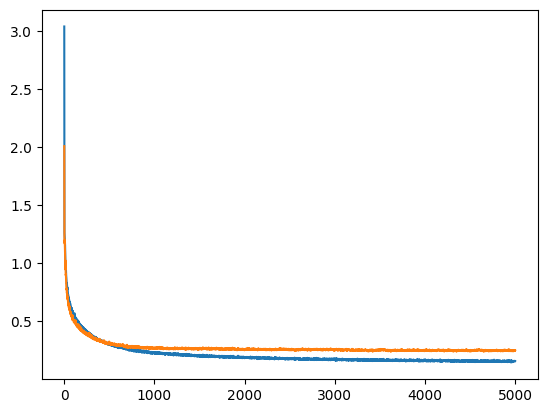

In [31]:
#Documents
#Logarithm
#No keeping one sample together
# layers 8, 32, 64, 128, 256, 128, 64, 32, 8
#batch size = 100
#Bigger network (64 neurons max)
#lr=0.001
#dropout =0.02

plt.plot(train_losses)
plt.plot(val_losses) #lr=0.01

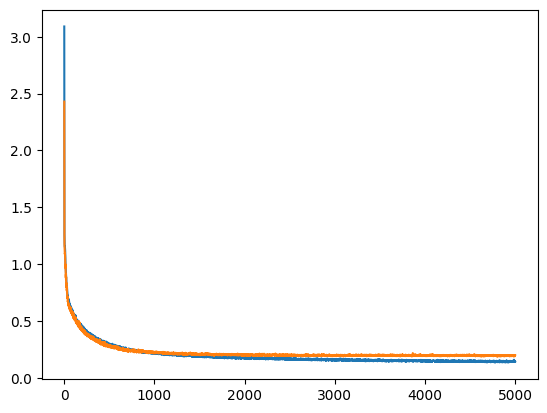

In [31]:
#Documents
#Logarithm
#No keeping one sample together
# layers 8, 32, 64, 128, 64, 32, 8
#batch size = 100
#Bigger network (64 neurons max)
#lr=0.001
#dropout =0.02

plt.plot(train_losses)
plt.plot(val_losses) #lr=0.001

## Loading pretrained model

In [35]:
path = models_path[object_name] + 'model_regression_Documents_XVIII_century_sample_split_logarithm_Al_S_Cr_Mn_Co_Cu_Zn_Pb_2024_11_15_08_33_30'

model = InksNet().to(device)
model.load_state_dict(torch.load(path))

/tmp/ipykernel_3476/3348439873.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path))


<All keys matched successfully>

## Prediction on test set

In [32]:
model.eval()
loss_fn = CustomLoss()

running_tloss = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    if i==0:
        out = outputs
        lab = labels
        res = abs(outputs-labels)
    else:
        res = torch.concat((res, abs(outputs-labels)), axis=0)
        lab = torch.concat((lab, labels), axis=0)
        out = torch.concat((out, outputs), axis=0)
    running_tloss += loss.item()
    
mean_loss = running_tloss/len(test_loader)

Consecutive inks from test set are in lab tensor (484 examples, 8 elements/coordinates):

In [33]:
lab

tensor([[ 0.2679, -3.6758, -8.8789,  ..., -4.4476, -7.2315, -2.4456],
        [ 0.4346, -4.2934, -7.9849,  ..., -5.3670, -2.7752, -2.2818],
        [ 2.3251, -3.9729, -7.9471,  ..., -3.1096, -4.3394, -0.8070],
        ...,
        [ 2.4852, -3.6512, -8.5332,  ..., -3.5571, -4.5304, -0.3241],
        [ 0.5240, -6.4667, -8.6070,  ..., -3.9199, -4.7147, -1.4493],
        [ 0.8370, -4.7660, -7.7841,  ..., -3.0095, -6.6349, -0.5688]],
       device='cuda:0')

Predictions are in out tensor (484 examples, 8 elements/coordinates):

In [34]:
out

tensor([[ 0.1395, -3.7975, -9.6458,  ..., -4.2859, -6.8409, -2.3356],
        [ 0.5893, -4.1291, -8.0533,  ..., -5.2431, -2.8619, -2.1444],
        [ 2.6580, -4.0044, -8.0216,  ..., -3.1124, -4.3269, -0.6131],
        ...,
        [ 2.8180, -4.2258, -7.9899,  ..., -3.4975, -4.9301, -0.0537],
        [ 0.4412, -3.7859, -9.3230,  ..., -2.4512, -2.7650, -0.5367],
        [ 0.9060, -4.5817, -7.3938,  ..., -3.0948, -6.4273, -0.5921]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (lab) and prediction (out) are stored in res tensor (484 examples, 8 elements/coordinates):

In [35]:
res

tensor([[0.1284, 0.1217, 0.7669,  ..., 0.1618, 0.3906, 0.1100],
        [0.1547, 0.1643, 0.0684,  ..., 0.1239, 0.0867, 0.1374],
        [0.3330, 0.0316, 0.0745,  ..., 0.0028, 0.0125, 0.1940],
        ...,
        [0.3328, 0.5745, 0.5433,  ..., 0.0595, 0.3997, 0.2704],
        [0.0828, 2.6808, 0.7159,  ..., 1.4687, 1.9497, 0.9126],
        [0.0690, 0.1843, 0.3902,  ..., 0.0853, 0.2076, 0.0233]],
       device='cuda:0', grad_fn=<CatBackward0>)

To calculate mean error on consecutive coordinates run:

In [36]:
torch.mean(res, axis=0) 

tensor([0.1876, 0.1796, 0.3460, 0.1340, 0.1724, 0.1854, 0.1902, 0.1939],
       device='cuda:0', grad_fn=<MeanBackward1>)

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb.

Significance of elements: Cu >> Mn > Al > Zn > Pb > S > Cr > Co >> all the others.

Later on we will modify loss function so that errors from coordinates will be weighted depending on the importance of chemical elements.

To calculate mean error on all coordinates run:

In [37]:
torch.mean(res)

tensor(0.1986, device='cuda:0', grad_fn=<MeanBackward0>)

## Saving the model

In [83]:
sample_together = 'sample_together' if keep_sample_together else 'sample_split'
outer_removed = 'outer_removed' if remove_outer else 'outer_not_removed'

elements = '_'.join(elements_to_keep)
settings_str = object_name + '_' + sample_together + '_' + preprocessing_method + '_' + \
                outer_removed + '_' + elements + '_'

import time
ts = time.time()
import datetime
now = datetime.datetime.fromtimestamp(ts).strftime('%Y_%m_%d_%H_%M_%S')

#torch.save(model.state_dict(), models_path[object_name]+'model_regression_' + settings_str + now)

### Visualisations

In [39]:
dim_nr = 3
selected_outputs = out[:, dim_nr].cpu().detach().numpy()
selected_labels = lab[:, dim_nr].cpu().detach().numpy()

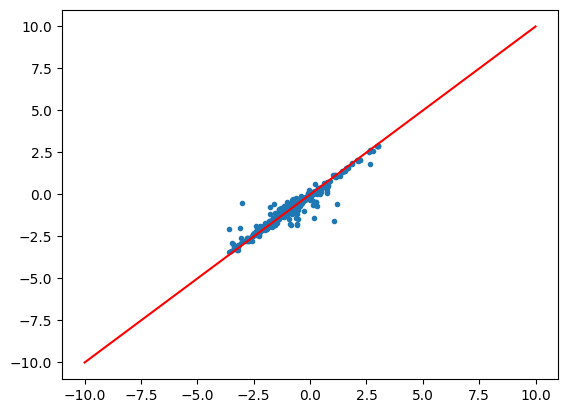

In [40]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [-10, 10],[-10, 10], 'red' )

## Quality of prediction: closest points

#### Creating df with means of classes

In [41]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds[object_name]]

In [42]:
train_val_df = pd.DataFrame(y_train.cpu())
train_val_df = pd.concat([train_val_df, 
                                    pd.DataFrame(y_val.cpu())])
train_val_df.columns = elements_names
train_val_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
train_val_df.reset_index(drop=True, inplace=True)

In [43]:
mean_df = train_val_df[['Sample_id']]

for name in elements_names:
    mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
    mean_df.drop_duplicates('Sample_id', inplace=True)
    
mean_df.sort_values(by='Sample_id', inplace=True)
mean_df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_44643/649964028.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_44643/649964028.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_44643/649964028.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

#### Checking if there is any chance for it to work: if classes in y_test are close to means of classes in train_val set

In [44]:
y_test_df = pd.DataFrame(y_test.cpu())
y_test_df.columns = elements_names
y_test_df.insert(0, 'Sample_id', test_order)
y_test_df.reset_index(drop=True, inplace=True)

In [45]:
closest = []
for i in range(y_test_df.shape[0]):
    which_row = (abs(y_test_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [46]:
len(closest)

656

In [47]:
y_test_df['Closest'] = closest

In [48]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] 

625

In [49]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] / len(closest)

0.9527439024390244

#### Now let's check if it works for the neural network's output.

In [50]:
model.eval()
outputs = model(X_test)

In [51]:
outputs_df = pd.DataFrame(outputs.cpu().detach().numpy())
outputs_df.columns = elements_names
outputs_df.insert(0, 'Real sample_id', test_order)
outputs_df.reset_index(drop=True, inplace=True)

In [52]:
closest = []
for i in range(outputs_df.shape[0]):
    which_row = (abs(outputs_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [53]:
len(closest)

656

In [54]:
outputs_df['Closest'] = closest

In [55]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0]

580

In [56]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0] / len(closest)

0.8841463414634146

In [57]:
outputs_df[outputs_df['Real sample_id'] == outputs_df['Closest']].shape[0] / len(closest)

0.8841463414634146

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from seaborn import heatmap

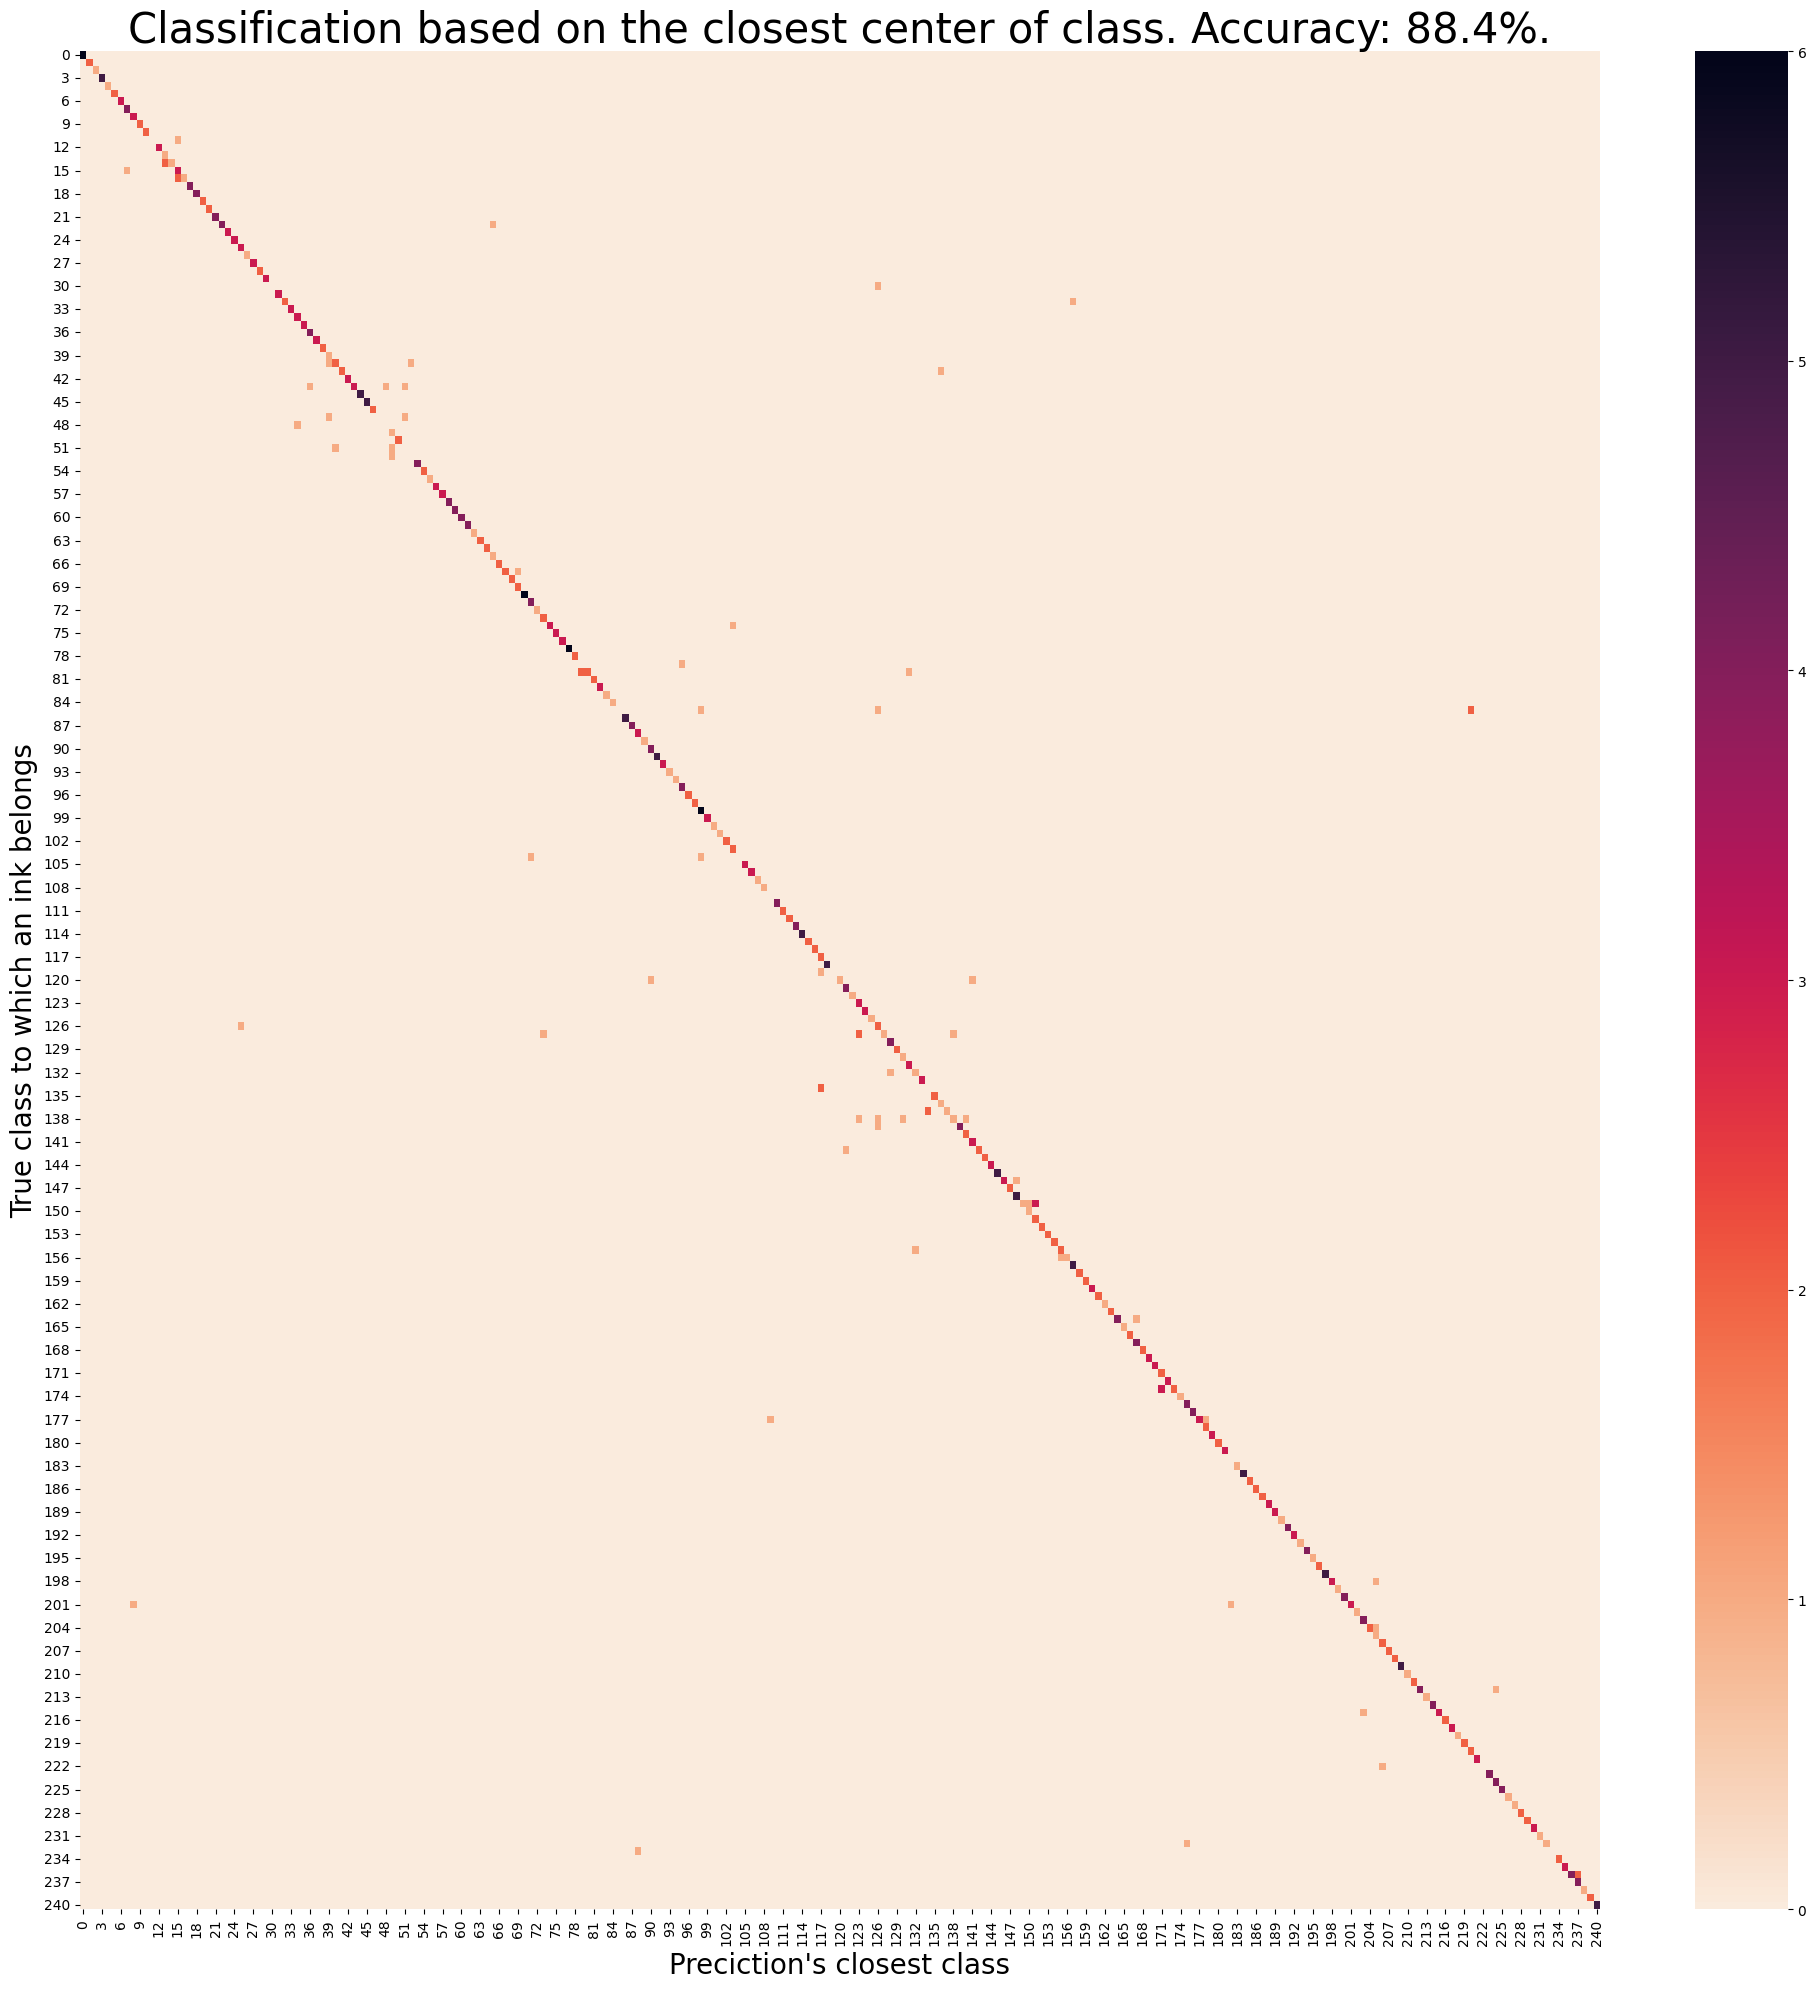

In [84]:
acc = np.round(100*outputs_df[outputs_df['Real sample_id'] == outputs_df['Closest']].shape[0] / len(closest), 1)
conf_mat = confusion_matrix(outputs_df['Real sample_id'], outputs_df['Closest'])


heatmap(conf_mat, cmap=sns.cm.rocket_r)
plt.ylabel('True class to which an ink belongs', size=20)
plt.xlabel("Preciction's closest class", size=20)
plt.rcParams['figure.figsize'] = [20, 20]
plt.title('Classification based on the closest center of class. Accuracy: '+str(acc)+'%.', size=30)
plt.tight_layout()
#plt.savefig('../figures/heatmap.png')

## Quality of prediction: confidence intervals

In [62]:
model.eval()
outputs = model(X_test)

In [63]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds[object_name]]

In [64]:
all_data_df = pd.DataFrame(y_train.cpu())
all_data_df = pd.concat([all_data_df, 
                        pd.DataFrame(y_val.cpu())])
all_data_df.columns = elements_names
all_data_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
all_data_df.reset_index(drop=True, inplace=True)

In [65]:
min_max_df = all_data_df[['Sample_id']]

for name in elements_names:
    min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    min_max_df[name + '_min'] = all_data_df.groupby('Sample_id')[name].transform('min')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
        
min_max_df.sort_values(by='Sample_id', inplace=True)
min_max_df.reset_index(drop=True, inplace=True)

max_df = min_max_df.iloc[:,1:(1+len(elements_names))]
max_df['Sample_id'] = min_max_df['Sample_id']
min_df = min_max_df.iloc[:,1+len(elements_names):]
min_df['Sample_id'] = min_max_df['Sample_id']

/tmp/ipykernel_44643/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
/tmp/ipykernel_44643/3264826654.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_44643/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/

In [66]:
mean_sd_df = all_data_df[['Sample_id']]

for name in elements_names:
    mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    mean_sd_df[name + '_sd'] = all_data_df.groupby('Sample_id')[name].transform(np.std)
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
mean_sd_df.sort_values(by='Sample_id', inplace=True)
mean_sd_df.reset_index(drop=True, inplace=True)

upper_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values + \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
upper_bound_df = pd.DataFrame(upper_bound_df, columns=elements_names)
upper_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

lower_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values - \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
lower_bound_df = pd.DataFrame(lower_bound_df, columns=elements_names)
lower_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

/tmp/ipykernel_44643/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_44643/2008320981.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_44643/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

In [67]:
min_max_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater_than_min = test_example.cpu().detach().numpy() > \
                    np.array(min_df.loc[min_df['Sample_id'] == sample_id, min_df.columns != 'Sample_id'])
    
    less_than_max = test_example.cpu().detach().numpy() < \
                    np.array(max_df.loc[max_df['Sample_id'] == sample_id, max_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater_than_min, less_than_max)
    
    #print(res)
    min_max_res_list.append(res)

In [68]:
sd_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater = test_example.cpu().detach().numpy() > \
    np.array(lower_bound_df.loc[lower_bound_df['Sample_id'] == sample_id, lower_bound_df.columns != 'Sample_id'])
    
    less = test_example.cpu().detach().numpy() < \
    np.array(upper_bound_df.loc[upper_bound_df['Sample_id'] == sample_id, upper_bound_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater, less)
    
    #print(res)
    sd_res_list.append(res)

In [69]:
elements_names

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb']

Percentage of points inside mean +- 2 standard deviations interval:

In [70]:
np.array(sd_res_list).mean()

0.8140243902439024

On consecutive coordinates:

In [71]:
np.array(sd_res_list).mean(0)

array([[0.87195122, 0.87195122, 0.90091463, 0.72103659, 0.80335366,
        0.75152439, 0.83384146, 0.75762195]])

Percentage of points inside min-max interval:

In [73]:
np.array(min_max_res_list).mean()

0.7286585365853658

On consecutive coordinates:

In [74]:
np.array(min_max_res_list).mean(0)

array([[0.77134146, 0.78353659, 0.85670732, 0.63109756, 0.69207317,
        0.66158537, 0.75152439, 0.68140244]])

### Visualisations of mean +- 2 * standard deviation intervals

In [75]:
# fig, ax = plt.subplots(2,4, figsize=(15,8))
# plt.suptitle('Mean +- two standard deviations in classes')
# for sample_id in range(min_max_df.shape[0]):
#     for element in range(int((min_max_df.shape[1]-1)/2)):
#         ax[element//4][element%4].hlines(y=sample_id, xmin=lower_bound_df.iloc[sample_id, element], 
#                   xmax=upper_bound_df.iloc[sample_id, element], 
#                   color="blue", linewidth=1)
#         ax[element//4][element%4].set_title(elements_names[element], size=15)
#         if element == 5:
#             ax[element//4][element%4].set_xlim([-0.2, 2.0])
#         if element == 0 or element == 4:
#             ax[element//4][element%4].set_ylabel('Class number')
    
#plt.savefig(figures_path + 'intervals.png', dpi=300)

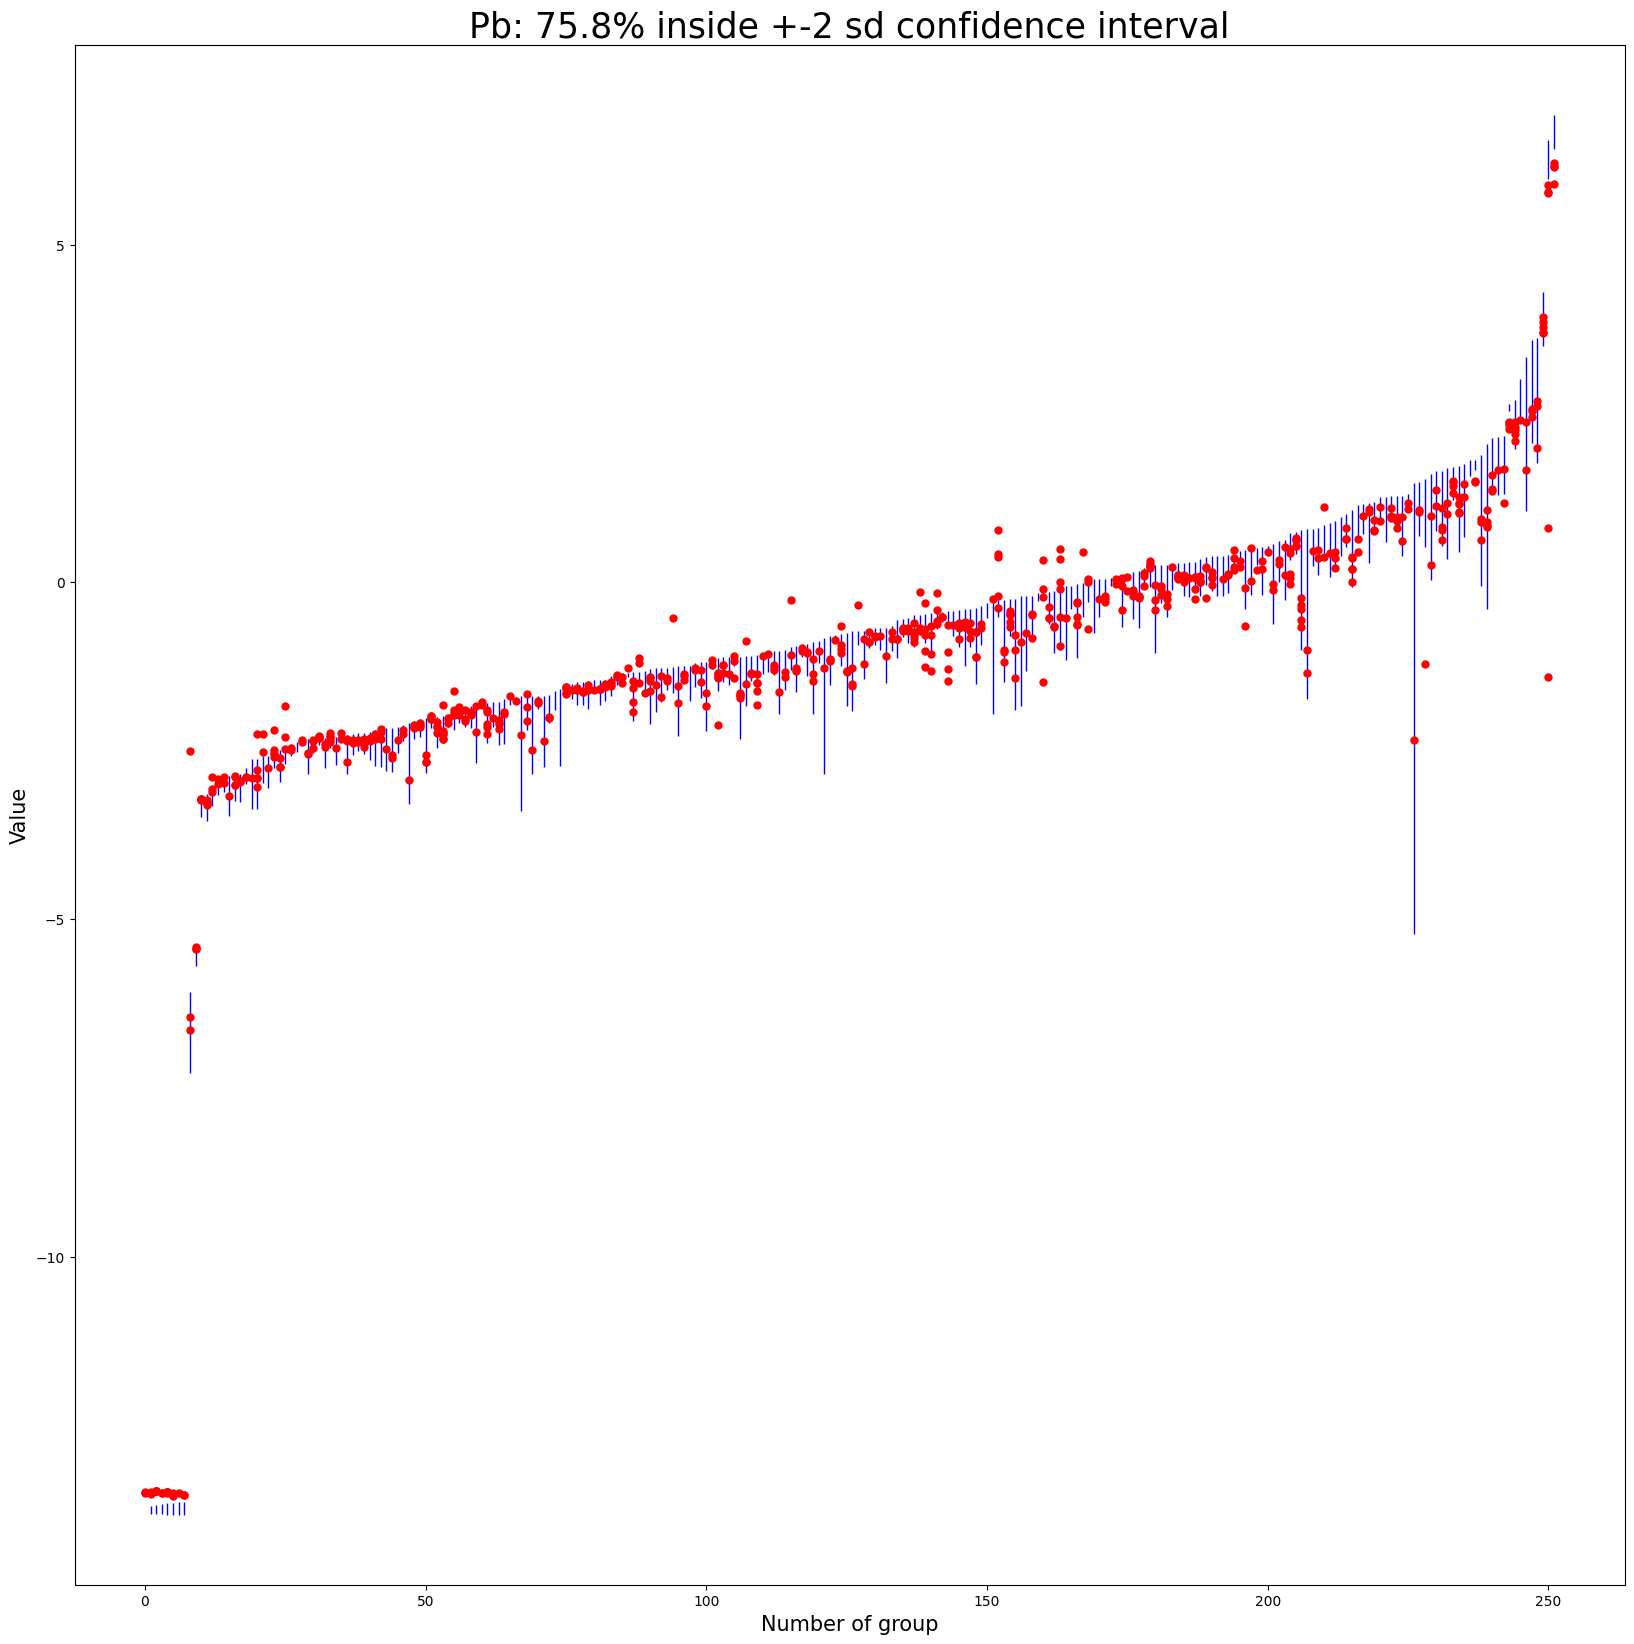

In [95]:
element = 7
percentage_correct = np.round(100*(np.array(sd_res_list).mean(0))[0,element], 1)

sorted_upper_bound_df = upper_bound_df.sort_values(upper_bound_df.columns[element])
sorted_upper_bound_df.reset_index(drop=True, inplace=True)
sorted_lower_bound_df = lower_bound_df.iloc[upper_bound_df.sort_values(upper_bound_df.columns[element]).index,:]
sorted_lower_bound_df.reset_index(drop=True, inplace=True)

for sample_id in range(sorted_lower_bound_df.shape[0]):
    plt.vlines(x=sample_id, ymin=sorted_lower_bound_df.iloc[sample_id, element], 
                  ymax=sorted_upper_bound_df.iloc[sample_id, element], 
                  color="blue", linewidth=1)
    
for row in range(outputs_df.shape[0]):
    new_index = sorted_upper_bound_df[sorted_upper_bound_df['Sample_id']==outputs_df['Real sample_id'][row]].index
    plt.plot(new_index, outputs_df.iloc[row,element+1], 'ro', markersize=5)
        
plt.xlabel('Number of group',size=15)
plt.ylabel('Value',size=15)
plt.title(str(outputs_df.columns[element+1]) + ': '+str(percentage_correct) +'% inside +-2 sd confidence interval', size=25)
plt.rcParams['figure.figsize'] = [20, 20]
#plt.savefig('../figures/confidence_intervals_'+str(outputs_df.columns[element+1]))

### Visualisations of min-max intervals

In [77]:
# fig, ax = plt.subplots(2,4, figsize=(10,5))
# for sample_id in range(min_max_df.shape[0]):
#     for element in range(int((min_max_df.shape[1]-1)/2)):
#         ax[element//4][element%4].vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
#                   ymax=min_max_df.iloc[sample_id, element+1], 
#                   color="blue", linewidth=1)
        #ax[element%4][element%2].set_title(elements_names[element])

For a single element:

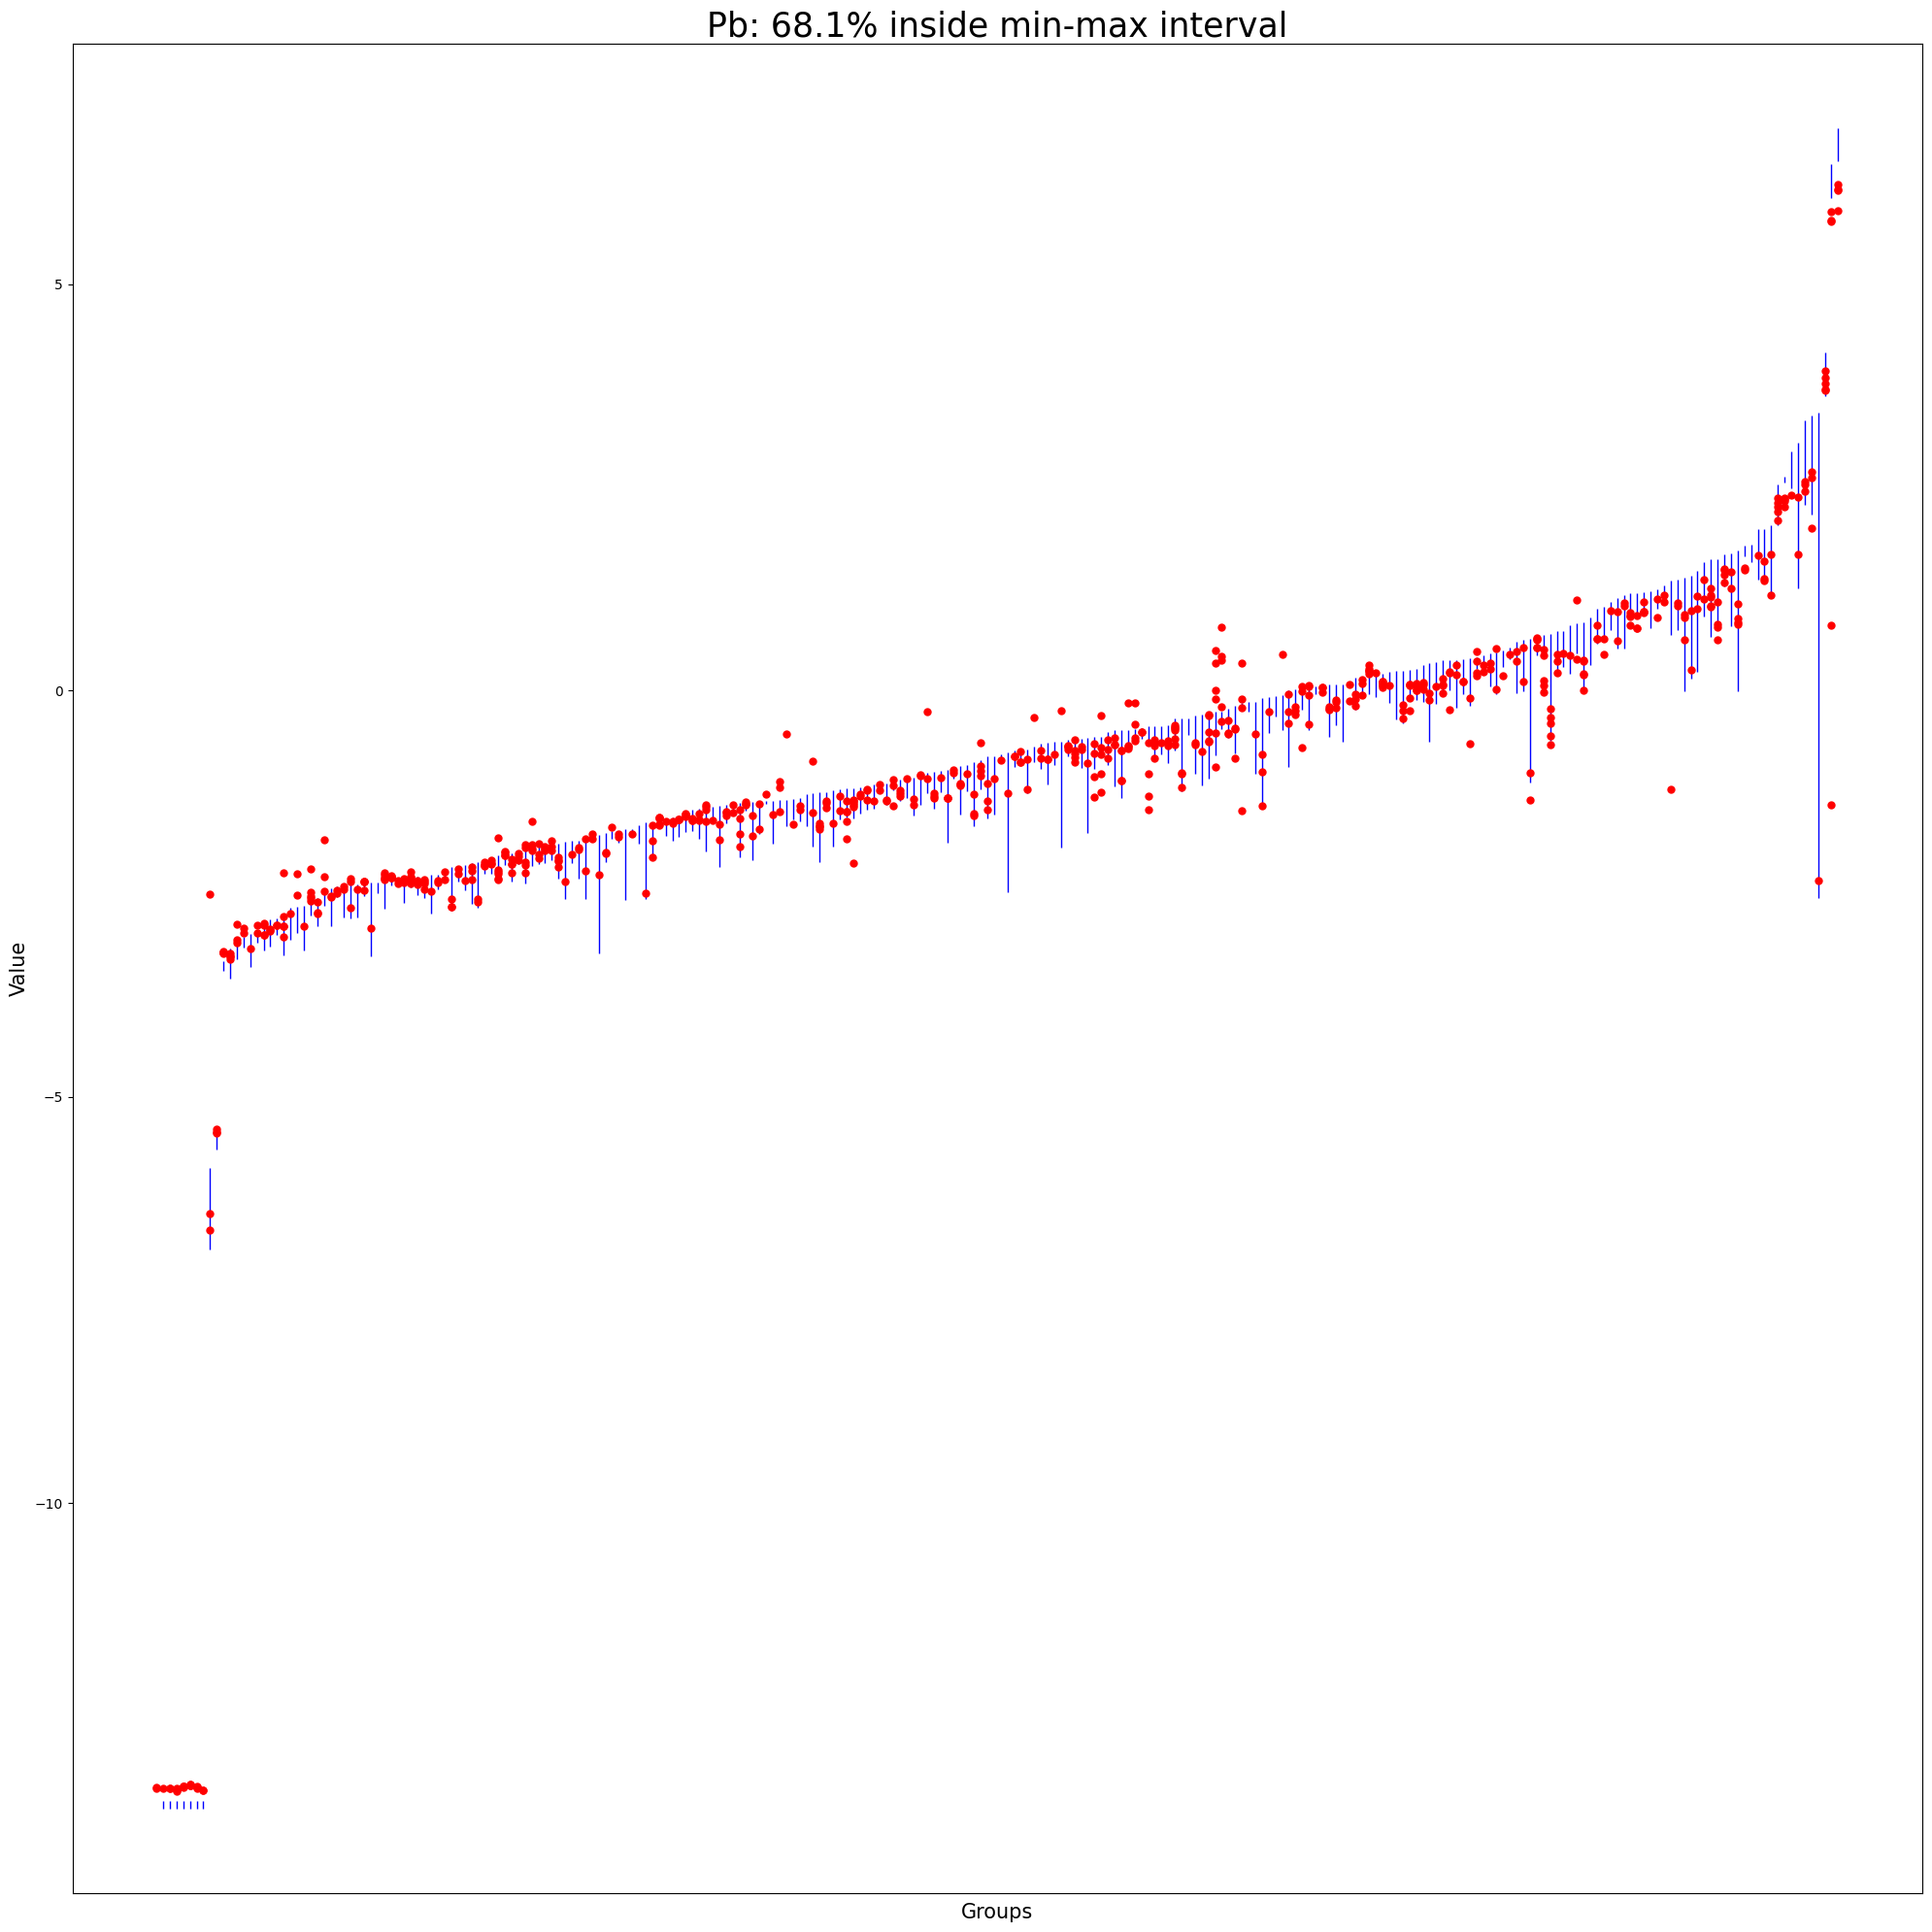

In [104]:
element = 7
percentage_correct = np.round(100*(np.array(min_max_res_list).mean(0))[0,element], 1)

sorted_min_max_df = min_max_df.sort_values(min_max_df.columns[element+1])
sorted_min_max_df.reset_index(drop=True, inplace=True)

for sample_id in range(sorted_min_max_df.shape[0]):
    plt.vlines(x=sample_id, ymin=sorted_min_max_df.iloc[sample_id, element+9], 
                  ymax=sorted_min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)

for row in range(outputs_df.shape[0]):
    new_index = sorted_min_max_df[sorted_min_max_df['Sample_id']==outputs_df['Real sample_id'][row]].index
    plt.plot(new_index, outputs_df.iloc[row,element+1], 'ro', markersize=5)
        
plt.xticks([], [])
plt.xlabel('Groups',size=15)
plt.ylabel('Value',size=15)
plt.title(str(outputs_df.columns[element+1]) + ': '+str(percentage_correct) +'% inside min-max interval', size=25)
plt.rcParams['figure.figsize'] = [20, 20]
plt.tight_layout()

#plt.savefig('../figures/min_max_intervals_'+str(outputs_df.columns[element+1]))

## Interpretability